# Análisis del Titanic


## Indice
- [Abstract](#abstract)
- [Preentrega: EDA, nulos y graficos](#preentrega-eda-nulos-y-graficos)
  - [Exploracion de datos](#exploracion-de-datos)
  - [Tamano del DataSet](#tamano-del-dataset)
  - [Informacion sobre la estructura](#informacion-sobre-la-estructura)
  - [Valores nulos](#valores-nulos)
  - [Manejo de valores nulos](#manejo-de-valores-nulos)
  - [Analisis de correlacion](#analisis-de-correlacion)
  - [Rellenando valores nulos de edad](#rellenando-valores-nulos-de-edad)
  - [Descripcion y estadistica de las columnas numericas](#descripcion-y-estadistica-de-las-columnas-numericas)
- [Proyecto final parte III](#proyecto-final-parte-iii)
  - [Feature Selection](#feature-selection)
  - [Modelo de clasificacion](#modelo-de-clasificacion)
  - [Metricas](#metricas)
  - [Modelo opcional: Random Forest](#modelo-opcional-random-forest)
  - [Comparacion de modelos](#comparacion-de-modelos-resumen)
- [Conclusiones](#conclusiones)
- [Clustering no supervisado](#clustering-no-supervisado)
  - [KMeans](#kmeans)
  - [Clustering jerarquico](#clustering-jerarquico)
- [Nota Final](#nota-final)


## Abstract

El presente proyecto tiene como objetivo analizar el conjunto de datos del Titanic con el fin de identificar
los factores que influyeron en la supervivencia de los pasajeros durante el naufragio. A través de técnicas
de análisis exploratorio de datos, visualización y modelado predictivo, se busca comprender qué variables
tuvieron mayor impacto en la probabilidad de supervivencia y evaluar la capacidad de un modelo de
clasificación para predecir dicho resultado.

La motivación de este análisis surge del interés por aplicar conceptos fundamentales de Ciencia de Datos
sobre un dataset clásico, ampliamente utilizado en el ámbito académico, que permite explorar tanto
relaciones estadísticas como patrones sociales presentes en los datos. El proyecto está orientado a un
público con conocimientos iniciales en análisis de datos y aprendizaje automático, como estudiantes o
personas interesadas en comprender el proceso completo de un flujo de trabajo en Data Science.

Durante el desarrollo, se realizó una limpieza y preparación de los datos, abordando especialmente el
tratamiento de valores faltantes. En particular, se aplicó una estrategia de imputación de la variable
Edad basada en la mediana agrupada por sexo y clase del pasajero, permitiendo conservar información
relevante sin introducir sesgos significativos. Posteriormente, se llevó a cabo un análisis exploratorio
mediante gráficos multivariados que evidencian una fuerte relación entre la supervivencia, el sexo y la
clase socioeconómica.

En una etapa posterior, se aplicó una técnica de selección de variables para reducir la dimensionalidad
del dataset y conservar únicamente las características más relevantes. Con estas variables se entrenó un
modelo de regresión logística, evaluando su desempeño a través de métricas estándar como accuracy,
precision, recall y matriz de confusión.

Los resultados obtenidos muestran que variables como el sexo, la clase del pasajero y la tarifa abonada
tienen una influencia significativa en la supervivencia. Si bien el modelo presenta un desempeño
aceptable, se reconocen limitaciones propias del tamaño del dataset y de la simplicidad del enfoque
utilizado, dejando abiertas posibilidades de mejora para futuros trabajos.


## Preentrega: EDA, nulos y graficos

[Click para ver DataSet](https://www.kaggle.com/datasets/yasserh/titanic-dataset/data?select=Titanic-Dataset.csv)




### Exploracion de datos

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

url_data = (r'https://raw.githubusercontent.com/rdalvarez/CoderHouse-DataScienceI/refs/heads/main/Titanic-Dataset.csv')
df = pd.read_csv(url_data)
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Tamano del DataSet


In [ ]:
print("Registros, columnas: ", df.shape)

Registros, columnas:  (891, 12)


### Informacion sobre la estructura

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Valores nulos

In [ ]:
nulos_col = df.isnull().sum()
nulos_col

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Manejo de valores nulos


La columna "Cabin" tiene muchos valores nulos, por lo tanto la borro y como solo tengo 2 registros de la columna Embarked vacios los seteo en S

In [ ]:
print('Borrando columna Cabin')
df.drop(columns=['Cabin'], inplace=True)

print('Seteando default en "Embarked" con S')
df['Embarked'] = df['Embarked'].fillna('S')

nulos_col = df.isnull().sum()
nulos_col

Borrando columna Cabin
Seteando default en "Embarked" con S


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Analisis de correlacion


In [ ]:
df.corr(numeric_only=True)['Age'].abs()

,Age
PassengerId,0.036847
Survived,0.077221
Pclass,0.369226
Age,1.000000
SibSp,0.308247
Parch,0.189119
Fare,0.096067


### Calculando edad mediana de los pasajeros por Sexo y Clase.

In [ ]:
df_Age_mean=df.groupby(['Sex', 'Pclass']).median(numeric_only=True)['Age']
df_Age_mean

Sex     Pclass
female  1         35.0
        2         28.0
        3         21.5
male    1         40.0
        2         30.0
        3         25.0
Name: Age, dtype: float64

## Rellenando valores nulos de edad

In [ ]:
df['Age']=df.groupby(['Sex','Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Descripcion y estadistica de las columnas numericas

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.112424,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.304424,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,21.500000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,36.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df['Survived'].value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


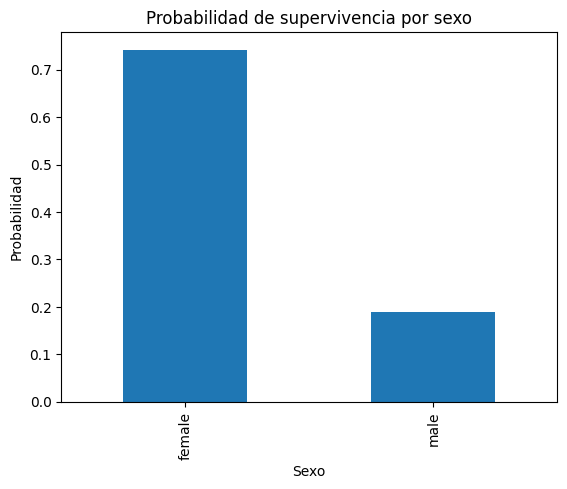

In [ ]:
df.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.title('Probabilidad de supervivencia por sexo')
plt.xlabel('Sexo')
plt.ylabel('Probabilidad')
plt.show()

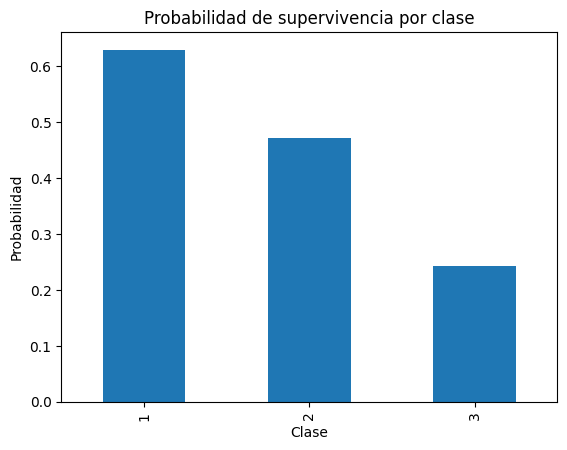

In [ ]:
df.groupby('Pclass')['Survived'].mean().plot(kind='bar')
plt.title('Probabilidad de supervivencia por clase')
plt.xlabel('Clase')
plt.ylabel('Probabilidad')
plt.show()

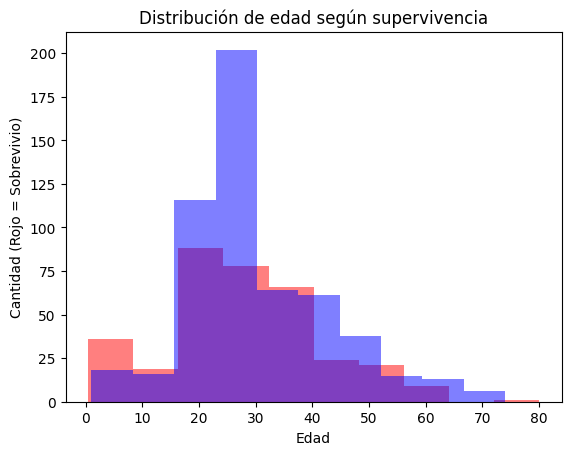

In [ ]:
df[df['Survived']==1]['Age'].plot(kind='hist', alpha=0.5, color='red')
df[df['Survived']==0]['Age'].plot(kind='hist', alpha=0.5, color='blue')
plt.title('Distribución de edad según supervivencia')
plt.xlabel('Edad')
plt.ylabel('Cantidad (Rojo = Sobrevivio)')
plt.show()

Este gráfico permite observar la distribución de edades según la supervivencia. Se aprecia que los
pasajeros más jóvenes presentan una mayor densidad de supervivencia, lo cual refuerza la hipótesis
de que la edad fue un factor relevante durante el rescate.


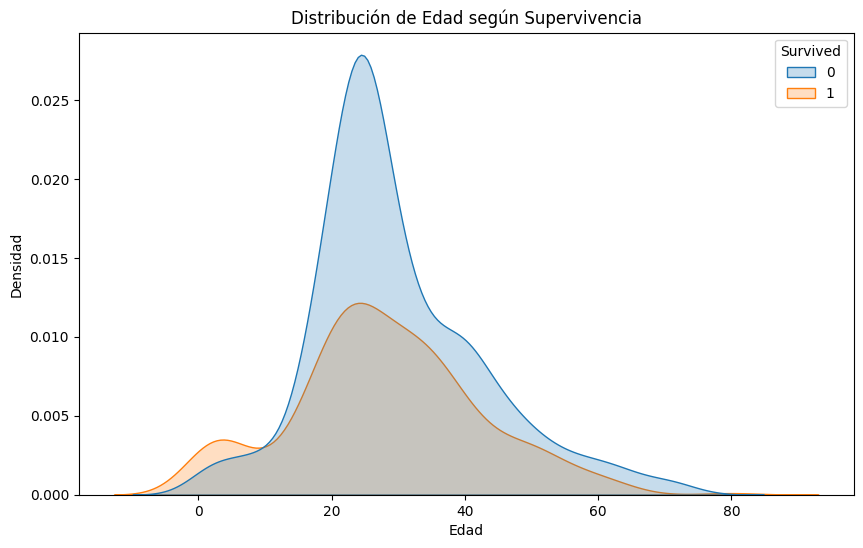

holi


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='Age', hue='Survived', fill=True)
plt.title('Distribución de Edad según Supervivencia')
plt.xlabel('Edad')
plt.ylabel('Densidad')
plt.show()


## Proyecto final parte III



### Feature Selection


In [ ]:
# Librerias
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder


In [ ]:
# Me hago una copia del DT
df_model = df.copy()

# Elimino las columnas que no son numéricas y aportan al modelo
columns_to_drop = ['Name', 'Ticket', 'Cabin']
df_model = df_model.drop(columns=columns_to_drop, errors='ignore')

# Codificación de variables categóricas
le = LabelEncoder()
df_model['Sex'] = le.fit_transform(df_model['Sex'])
df_model['Embarked'] = le.fit_transform(df_model['Embarked'])

# Defino X e y
X = df_model.drop('Survived', axis=1)
y = df_model['Survived']

Previo a la aplicación de Feature Selection, se eliminaron variables categóricas
no numéricas y columnas identificatorias como Name, Ticket y Cabin, ya que no
aportan información directa al modelo predictivo o requieren un procesamiento
adicional que excede el alcance del presente trabajo.


In [ ]:
selector = SelectKBest(score_func=f_classif, k=5)
X_selected = selector.fit_transform(X, y)

# Features seleccionadas
selected_features = X.columns[selector.get_support()]
selected_features


Index(['Pclass', 'Sex', 'Parch', 'Fare', 'Embarked'], dtype='object')

### Modelo de clasificacion


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [ ]:
X_final = df_model[selected_features]
y = df_model['Survived']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.3,
    random_state=42
)


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

Se entrenó un modelo de Regresión Logística utilizando las variables seleccionadas
en la etapa de Feature Selection, con el objetivo de predecir la supervivencia de
los pasajeros del Titanic.


### Metricas


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
y_pred = model.predict(X_test)


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.7723880597014925

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.80      0.80       157
           1       0.72      0.74      0.73       111

    accuracy                           0.77       268
   macro avg       0.77      0.77      0.77       268
weighted avg       0.77      0.77      0.77       268



### Interpretacion del Classification Report (Regresion Logistica)

- **Accuracy (0.77):** el modelo clasifica correctamente el 77% del conjunto de test.
- Para la clase **1 (Survived)**:
  - **Precision (0.72):** de todos los que el modelo predijo como “sobrevive”, el 72% realmente sobrevivió.
  - **Recall (0.74):** de todos los que realmente sobrevivieron, el modelo identificó correctamente el 74%.
  - **F1-score (0.73):** equilibrio entre precision y recall.

El conjunto de test tiene **157 no sobrevivientes** y **111 sobrevivientes**, por lo que conviene observar
las métricas por clase y no solo el accuracy.


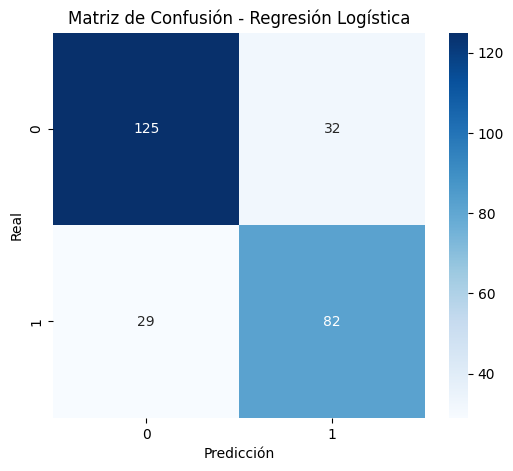

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()



### Interpretacion de la Matriz de confusion (Regresion Logistica)

- **TN (125):** pasajeros que **no sobrevivieron** y el modelo predijo correctamente **no sobrevivió**.
- **FP (32):** pasajeros que **no sobrevivieron** pero el modelo predijo **sobrevivió** (error).
- **FN (29):** pasajeros que **sobrevivieron** pero el modelo predijo **no sobrevivió** (error).
- **TP (82):** pasajeros que **sobrevivieron** y el modelo predijo correctamente **sobrevivió**.

En este caso, el modelo acierta **207 de 268** casos (Accuracy ≈ **0.77**).  
Un punto relevante es que existen **29 falsos negativos (FN)**: sobrevivientes reales que el modelo no detecta.


### Modelo opcional: Random Forest


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report (RF):\n")
print(classification_report(y_test, y_pred_rf))


Accuracy Random Forest: 0.7985074626865671

Classification Report (RF):

              precision    recall  f1-score   support

           0       0.81      0.85      0.83       157
           1       0.78      0.72      0.75       111

    accuracy                           0.80       268
   macro avg       0.79      0.79      0.79       268
weighted avg       0.80      0.80      0.80       268



### Interpretacion del Classification Report (Random Forest)

El modelo Random Forest logra un **accuracy de 0.80**, mejorando levemente a la Regresión Logística.

- Para la clase **1 (Survived)**:
  - **Precision (0.78):** mejora respecto a Logística (0.72). Cuando RF predice “sobrevive”, suele acertar más.
  - **Recall (0.72):** baja levemente respecto a Logística (0.74). Detecta un poco menos de sobrevivientes reales.
  - **F1-score (0.75):** mejora general del balance precision/recall para la clase 1.

En resumen, Random Forest aumenta el rendimiento global, pero cambia el perfil de errores:
es más “conservador” al predecir sobrevivientes (menos falsos positivos, pero también menos recall).


### Comparacion de Modelos (resumen)

- **Regresión Logística:** Accuracy 0.77, mejor **recall** para sobrevivientes (0.74).
- **Random Forest:** Accuracy 0.80, mejor **precision** y **F1** para sobrevivientes (0.78 / 0.75).

Para este proyecto, ambos modelos son aceptables. Random Forest ofrece una mejora leve en performance general,
mientras que Logística resulta más simple e interpretable.


## Conclusiones

A partir del análisis realizado, se logró construir un modelo de clasificación
capaz de predecir la supervivencia de los pasajeros del Titanic utilizando un
conjunto reducido de variables relevantes.

Las variables seleccionadas mediante Feature Selection muestran una relación
significativa con la supervivencia, destacándose principalmente el sexo del
pasajero, la clase socioeconómica y la tarifa abonada.

El modelo de regresión logística obtuvo un desempeño aceptable según las métricas
calculadas, aunque presenta limitaciones propias del tamaño del dataset y la
simplicidad del enfoque utilizado.

Como comparación, el modelo **Random Forest** mejoró levemente el desempeño global (Accuracy ≈ **0.80**), aumentando la **precision** y el **F1** para la clase "Survived", aunque con un **recall** ligeramente menor respecto de la regresión logística. Esto muestra un trade-off entre reducir falsos positivos y detectar la mayor cantidad posible de sobrevivientes.

Como trabajo futuro, podría evaluarse el uso de otros modelos de clasificación
más complejos o técnicas de optimización para mejorar el rendimiento predictivo.


## Clustering no supervisado
Como análisis adicional, se aplicaron técnicas de clustering con el objetivo de identificar
grupos de pasajeros con características similares, sin utilizar la variable objetivo
Survived. Este enfoque permite explorar la estructura subyacente del dataset desde una
perspectiva no supervisada.


### KMeans


In [ ]:
from sklearn.preprocessing import StandardScaler

# Dataset para clustering (sin Survived)
df_cluster = df_model[['Age', 'Fare', 'Pclass', 'Sex']].copy()

# Escalado
scaler = StandardScaler()
df_cluster_scaled = scaler.fit_transform(df_cluster)


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df_cluster_scaled)

df_cluster['Cluster'] = clusters


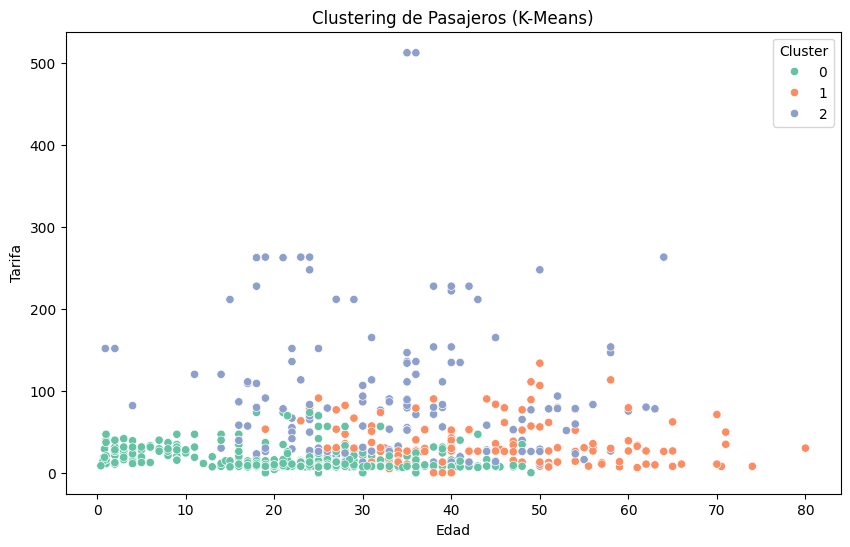

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_cluster,
    x='Age',
    y='Fare',
    hue='Cluster',
    palette='Set2'
)
plt.title('Clustering de Pasajeros (K-Means)')
plt.xlabel('Edad')
plt.ylabel('Tarifa')
plt.show()


El algoritmo K-Means permitió identificar tres grupos de pasajeros con características
similares en función de la edad, la tarifa abonada, el sexo y la clase. Se observa una
separación clara entre pasajeros con mayores tarifas y aquellos con menores recursos,
lo que refuerza la influencia del nivel socioeconómico en el perfil de los pasajeros.


### Clustering jerarquico


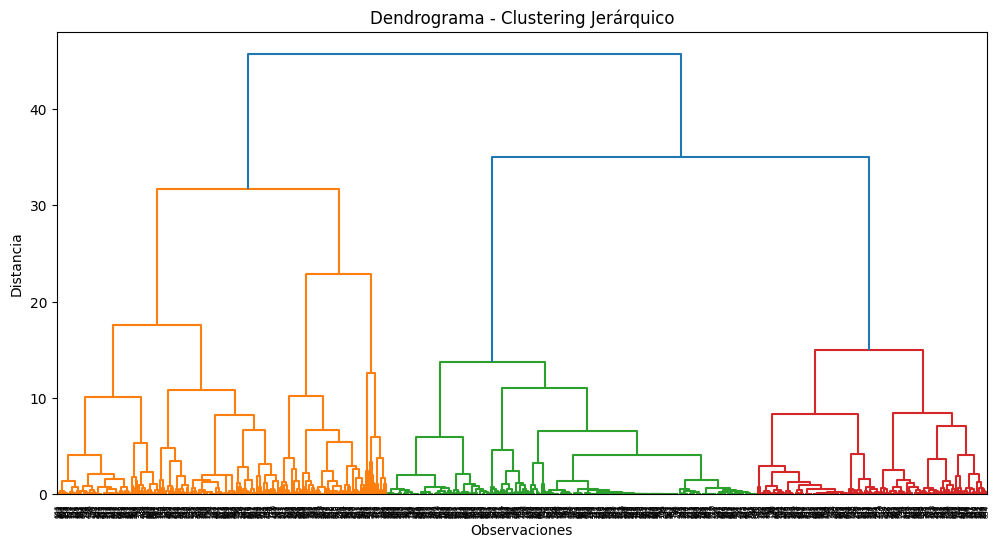

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(df_cluster_scaled, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linked)
plt.title('Dendrograma - Clustering Jerárquico')
plt.xlabel('Observaciones')
plt.ylabel('Distancia')
plt.show()


### Nota Final

El análisis de clustering fue incorporado como una herramienta exploratoria adicional,
con el objetivo de enriquecer la comprensión del dataset desde una perspectiva no
supervisada. Los resultados obtenidos no fueron utilizados para el entrenamiento del
modelo predictivo, sino como complemento al análisis exploratorio inicial.
